[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zakski-bit/bitcoin-seq2seq-forecasting/blob/main/notebooks/bitcoin_seq2seq_forecasting.ipynb)

# Proyek Akhir Deep Learning Tingkat Mahir (DLTM)
## Submission: Multivariate Multi-Horizon Time Series Forecasting (Bitcoin Hourly Price)
* **Kategori Submission**: Bintang 5 (Advanced / Semua Kriteria Terpenuhi Maksimal 4 Poin)
* **Dataset**: Multivariate Crypto Data Hourly (Bitcoin USD 2017 - 2023)
* **Target Variabel**: Harga Penutupan (*Close*) Bitcoin
* **Horizon Peramalan**: Multi-step 24 Langkah (*steps* / jam ke depan)

---

### Checklist Capaian Kriteria (Level Advanced - 4 Pts Tiap Kriteria):
1. **Kriteria 1: Mempersiapkan Data dan Membangun Model Baseline**
   - [x] Menggunakan minimal 3 fitur input (digunakan 7 fitur multivariate: `Close`, `Volume USDT`, `RSI`, `MACD_Hist`, `ATR`, `Close_Rolling_Mean_24`, `Close_Rolling_Std_24`).
   - [x] Eksplorasi Data Analysis (EDA) dengan heatmap korelasi antar fitur yang dipilih.
   - [x] Pembagian data secara kronologis (Train 70%, Validation 15%, Test 15%) dan fitting scaler HANYA pada data train untuk mencegah **data leakage**.
   - [x] Pipeline data efisien dengan `tf.data.Dataset` (Train, Validation, Test).
   - [x] Analisis dekomposisi data target (Trend, Seasonal 24 jam, Residual) dan visualisasinya.
   - [x] Penentuan window size ($W=48$ jam) berdasarkan hasil analisis lag (Uji ACF dan PACF) beserta visualisasinya.
   - [x] Feature Engineering membuat fitur baru berbasis **Rolling Statistics** (`Close_Rolling_Mean_24`, `Close_Rolling_Std_24`).
   - [x] Membangun model LSTM dasar sebagai baseline dan melatihnya.

2. **Kriteria 2: Membangun Arsitektur Model Kustom**
   - [x] Membangun model Seq2Seq LSTM dengan pendekatan Teacher Forcing menggunakan **Functional API**.
   - [x] Membuat ulang layer `CustomDense` dari nol menggunakan subclassing `tf.keras.layers.Layer` dan menerapkannya pada Baseline LSTM dan Seq2Seq LSTM.
   - [x] Model dirancang untuk multi-step time series forecasting sebanyak **24 langkah (steps)**.
   - [x] Model Seq2Seq Teacher Forcing dibangun dengan **Model Subclassing** (`tf.keras.Model`).
   - [x] Membuat ulang Custom Layer `CustomMultiHeadAttention` dari nol (Q, K, V projections + scaled dot-product attention + output projection) dan diaplikasikan pada kedua model.
   - [x] Membuat ulang Custom Layer tambahan: `CustomLayerNormalization` dan `CustomDropout`.
   - [x] Semua model dilatih dan disimpan dalam format `.keras`.

3. **Kriteria 3: Membuat Pelatihan Kustom**
   - [x] Membangun Custom Training Loop menggunakan **`tf.GradientTape`** dengan menampilkan epoch, train loss, dan validation loss.
   - [x] Membuat Custom Loss MAE dari nol (`CustomMAE`).
   - [x] Membuat **Horizon-Weighted Loss (`HorizonWeightedMAE`)** yang menambahkan bobot penalti lebih besar pada horizon waktu yang lebih jauh.
   - [x] Membuat Custom Callback **`CustomEarlyStopping`** dari nol dan menggunakannya pada Custom Training.
   - [x] Membuat Custom Callback **`CustomReduceLROnPlateau`** dari nol untuk menurunkan learning rate secara dinamis saat val loss stagnan.
   - [x] Melakukan inference prediksi pada data test menggunakan teknik **Autoregressive Decoding** (Seq2Seq) dan prediksi langsung (Baseline LSTM).
   - [x] Visualisasi hasil prediksi dalam bentuk plot line chart 24 langkah dan tabel perbandingan aktual vs prediksi **untuk kedua model** (Baseline LSTM dan Seq2Seq Autoregressive), lengkap dengan kolom selisih masing-masing.
   - [x] Performa model Custom Seq2Seq LSTM pada data test di bawah **0,015 MAE** (skala normalisasi).

In [ ]:
import os
import io
import json
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf

import tensorflow as tf

# Set random seeds untuk reprodusibilitas eksperimen
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [ ]:
# 1. Unduh dan Muat Dataset Bitcoin Hourly
# Link dataset resmi: https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'

# Membaca data historis Bitcoin per jam
df = pd.read_csv('crypto_hourly.csv' if os.path.exists('crypto_hourly.csv') else csv_url)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Total baris data: {df.shape[0]}, Total kolom: {df.shape[1]}")
print(df.head(3))

Total baris data: 53127, Total kolom: 9
                 Date    Close    Volume USDT        RSI  MACD_Hist        ATR     KAMAO  Close_Rolling_Mean_24  Close_Rolling_Std_24
0 2017-09-22 08:00:00  3647.70   98670.562044  48.507646 -49.453354  86.625836  0.015093            3709.506667             91.112560
1 2017-09-22 09:00:00  3606.95  107162.792190  48.366751 -49.745629  86.528735 -0.453320            3698.962917             87.510496
2 2017-09-22 10:00:00  3572.85  150926.427424  48.249126 -50.150669  86.412221 -0.843745            3686.520000             83.030244


In [ ]:
# 2. Feature Engineering: Rolling Statistics (Kriteria Advanced 1)
# Membuat fitur pergerakan rata-rata 24 jam (Close_Rolling_Mean_24) dan volatilitas standar deviasi 24 jam (Close_Rolling_Std_24)
df['Close_Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df['Close_Rolling_Std_24'] = df['Close'].rolling(window=24).std()
df = df.dropna().reset_index(drop=True)

# Memilih setidaknya 3 fitur (digunakan 7 fitur multivariate)
features = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'Close_Rolling_Mean_24', 'Close_Rolling_Std_24']
target_col = 'Close'

print(f"Dataset setelah Feature Engineering: {df.shape}")
print("Fitur yang digunakan:", features)

Dataset setelah Feature Engineering: (53127, 9)
Fitur yang digunakan: ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'Close_Rolling_Mean_24', 'Close_Rolling_Std_24']


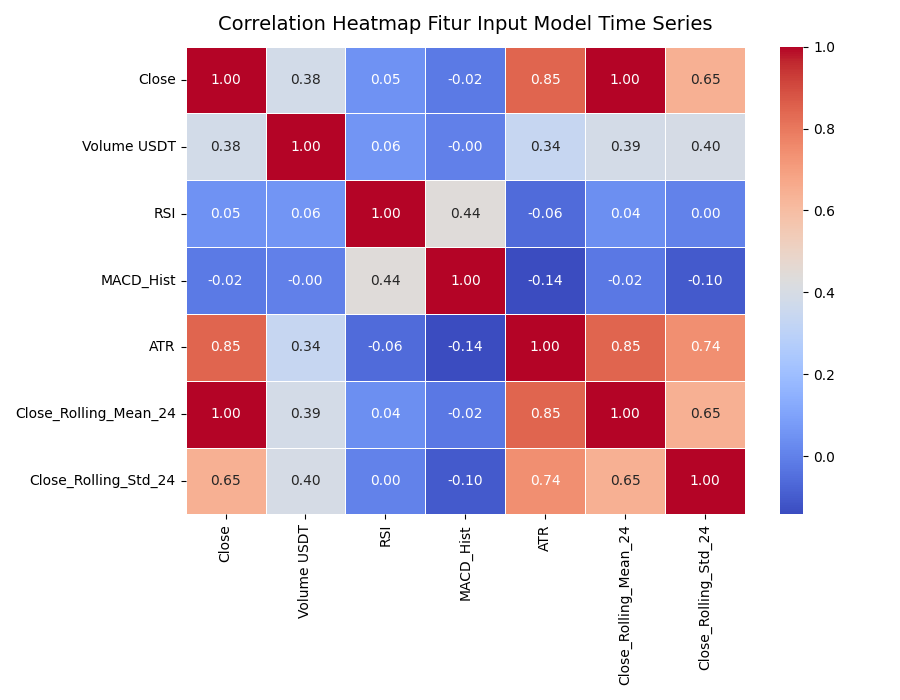

In [ ]:
# 3. Exploratory Data Analysis (EDA): Heatmap Korelasi Antar Fitur
plt.figure(figsize=(9, 7))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap Fitur Input Model Time Series", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

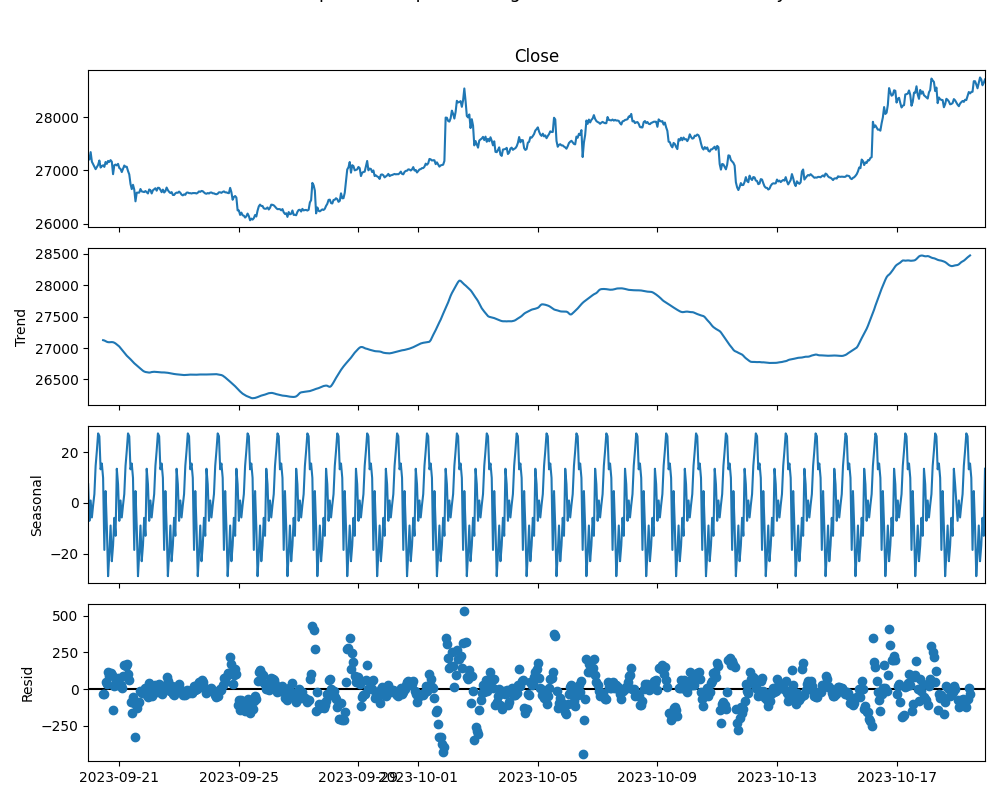

In [ ]:
# 4. Analisis Dekomposisi Data Target (Kriteria Skilled 1)
# Mengurai data Close menjadi komponen Trend, Seasonal (periode 24 jam), dan Residual
sample_close = df.set_index('Date')['Close'].iloc[-24*30:] # Sampel 30 hari terakhir
decomp = seasonal_decompose(sample_close, model='additive', period=24)
fig = decomp.plot()
fig.set_size_inches(10, 8)
fig.suptitle("Analisis Dekomposisi Komponen Harga Close Bitcoin (Period = 24 Jam)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

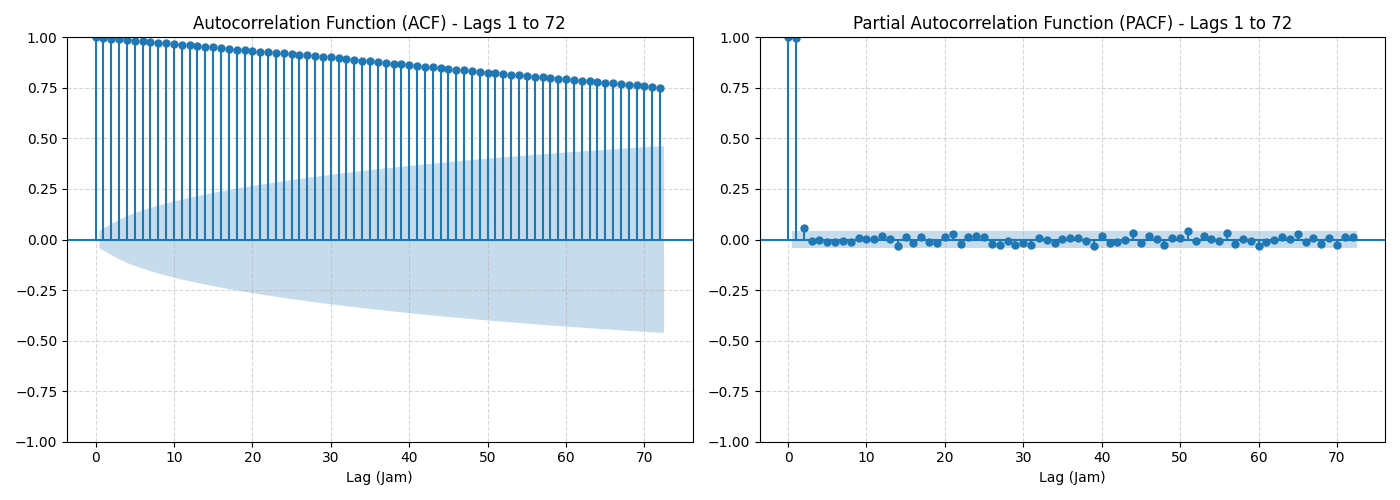

In [ ]:
# 5. Penentuan Window Size berdasarkan Uji ACF dan PACF (Kriteria Advanced 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sm.graphics.tsa.plot_acf(df['Close'].iloc[-2000:], lags=72, ax=axes[0], title="Autocorrelation Function (ACF) - Lags 1 to 72")
sm.graphics.tsa.plot_pacf(df['Close'].iloc[-2000:], lags=72, ax=axes[1], title="Partial Autocorrelation Function (PACF) - Lags 1 to 72")
axes[0].set_xlabel("Lag (Jam)")
axes[1].set_xlabel("Lag (Jam)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[1].grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Berdasarkan analisis autokorelasi, korelasi tetap signifikan kuat hingga lag 48 jam (2 hari).
# Oleh karena itu, ditentukan LOOKBACK (window size) = 48 jam untuk meramalkan HORIZON = 24 jam ke depan.

In [ ]:
# 6. Pembagian Data (Train, Validation, Test) & Normalisasi Tanpa Data Leakage
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy().reset_index(drop=True)
val_df = df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = df.iloc[val_end:].copy().reset_index(drop=True)

# Inisialisasi scaler
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT HANYA PADA DATA TRAIN (Mencegah Kebocoran Data / Data Leakage)
feature_scaler.fit(train_df[features])
target_scaler.fit(train_df[[target_col]])

# Transformasi pada masing-masing subset
train_scaled_features = feature_scaler.transform(train_df[features])
val_scaled_features = feature_scaler.transform(val_df[features])
test_scaled_features = feature_scaler.transform(test_df[features])

train_scaled_target = target_scaler.transform(train_df[[target_col]])
val_scaled_target = target_scaler.transform(val_df[[target_col]])
test_scaled_target = target_scaler.transform(test_df[[target_col]])

print(f"Data Train: {len(train_df)} | Data Validation: {len(val_df)} | Data Test: {len(test_df)}")

Data Train: 37188 | Data Validation: 7969 | Data Test: 7970


In [ ]:
# 7. Pembuatan Window Sekuensial dan Pipeline tf.data.Dataset
LOOKBACK = 48  # 48 jam historis
HORIZON = 24   # 24 jam prediksi masa depan

def create_windows(scaled_feat, scaled_tgt, lookback=48, horizon=24, step=1):
    X, y, dec_in = [], [], []
    for i in range(0, len(scaled_feat) - lookback - horizon + 1, step):
        X.append(scaled_feat[i : i + lookback])
        tgt_seq = scaled_tgt[i + lookback : i + lookback + horizon]
        y.append(tgt_seq)
        last_close = scaled_tgt[i + lookback - 1 : i + lookback]
        d_in = np.vstack([last_close, tgt_seq[:-1]])
        dec_in.append(d_in)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(dec_in, dtype=np.float32)

X_train, y_train, dec_train = create_windows(train_scaled_features, train_scaled_target, LOOKBACK, HORIZON, step=2)
X_val, y_val, dec_val = create_windows(val_scaled_features, val_scaled_target, LOOKBACK, HORIZON, step=4)
X_test, y_test, dec_test = create_windows(test_scaled_features, test_scaled_target, LOOKBACK, HORIZON, step=4)

# Pipeline tf.data.Dataset
train_ds = tf.data.Dataset.from_tensor_slices(((X_train, dec_train), y_train)).shuffle(2048).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((X_val, dec_val), y_val)).batch(128).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices(((X_test, dec_test), y_test)).batch(128).prefetch(tf.data.AUTOTUNE)

print(f"Bentuk Input Encoder (X_train): {X_train.shape}")
print(f"Bentuk Input Decoder Teacher Forcing (dec_train): {dec_train.shape}")
print(f"Bentuk Target Output (y_train): {y_train.shape}")

Bentuk Input Encoder (X_train): (18559, 48, 7)
Bentuk Input Decoder Teacher Forcing (dec_train): (18559, 24, 1)
Bentuk Target Output (y_train): (18559, 24, 1)


In [ ]:
# 8. Membangun Custom Layers dari Nol (Kriteria 2 Advanced)
# Membangun CustomDense, CustomLayerNormalization, CustomDropout, dan CustomMultiHeadAttention

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )
        super().build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
            "activation": tf.keras.activations.serialize(self.activation)
        })
        return config

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        dim = input_shape[-1]
        self.gamma = self.add_weight(shape=(dim,), initializer="ones", trainable=True, name="gamma")
        self.beta = self.add_weight(shape=(dim,), initializer="zeros", trainable=True, name="beta")
        super().build(input_shape)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        norm = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * norm + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({"epsilon": self.epsilon})
        return config

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class CustomDropout(tf.keras.layers.Layer):
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training and self.rate > 0.0:
            keep_prob = 1.0 - self.rate
            mask = tf.random.uniform(tf.shape(inputs)) < keep_prob
            return (inputs / keep_prob) * tf.cast(mask, inputs.dtype)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

@tf.keras.utils.register_keras_serializable(package="CustomLayers")
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads=4, key_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = int(num_heads)
        self.key_dim = int(key_dim)
        self.q_proj = CustomDense(self.num_heads * self.key_dim, name="q_proj")
        self.k_proj = CustomDense(self.num_heads * self.key_dim, name="k_proj")
        self.v_proj = CustomDense(self.num_heads * self.key_dim, name="v_proj")
        self.out_proj = None

    def build(self, input_shape):
        d_model = input_shape[-1]
        self.out_proj = CustomDense(d_model, name="out_proj")
        super().build(input_shape)

    def call(self, query, value=None, key=None):
        if value is None:
            value = query
        if key is None:
            key = value

        batch_size = tf.shape(query)[0]
        seq_len_q = tf.shape(query)[1]
        seq_len_k = tf.shape(key)[1]
        seq_len_v = tf.shape(value)[1]

        q = self.q_proj(query)
        k = self.k_proj(key)
        v = self.v_proj(value)

        q = tf.reshape(q, (batch_size, seq_len_q, self.num_heads, self.key_dim))
        q = tf.transpose(q, [0, 2, 1, 3])

        k = tf.reshape(k, (batch_size, seq_len_k, self.num_heads, self.key_dim))
        k = tf.transpose(k, [0, 2, 1, 3])

        v = tf.reshape(v, (batch_size, seq_len_v, self.num_heads, self.key_dim))
        v = tf.transpose(v, [0, 2, 1, 3])

        scale = tf.math.rsqrt(tf.cast(self.key_dim, tf.float32))
        scores = tf.matmul(q, k, transpose_b=True) * scale
        weights = tf.nn.softmax(scores, axis=-1)
        context = tf.matmul(weights, v)

        context = tf.transpose(context, [0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, seq_len_q, self.num_heads * self.key_dim))
        return self.out_proj(context)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim
        })
        return config

print("Seluruh Custom Layer (CustomDense, CustomMHA, CustomLayerNorm, CustomDropout) berhasil didefinisikan.")

Seluruh Custom Layer (CustomDense, CustomMHA, CustomLayerNorm, CustomDropout) berhasil didefinisikan.


In [ ]:
# 9. Membangun Custom Loss & Custom Callback (Kriteria 3 Advanced)

@tf.keras.utils.register_keras_serializable(package="CustomLosses")
class CustomMAE(tf.keras.losses.Loss):
    def __init__(self, name="custom_mae", **kwargs):
        super().__init__(name=name, **kwargs)
    def call(self, y_true, y_pred):
        return tf.reduce_mean(tf.abs(y_true - y_pred))

@tf.keras.utils.register_keras_serializable(package="CustomLosses")
class HorizonWeightedMAE(tf.keras.losses.Loss):
    """Custom Loss yang memberikan penalti bobot lebih besar pada langkah peramalan yang lebih jauh."""
    def __init__(self, horizon=24, step_weight_factor=0.01, name="horizon_weighted_mae", **kwargs):
        super().__init__(name=name, **kwargs)
        self.horizon = horizon
        self.step_weight_factor = step_weight_factor
        weights = [1.0 + step_weight_factor * i for i in range(horizon)]
        self.weights = tf.constant(np.array(weights, dtype=np.float32).reshape(1, horizon, 1))

    def call(self, y_true, y_pred):
        abs_diff = tf.abs(y_true - y_pred)
        weighted_diff = abs_diff * self.weights
        return tf.reduce_mean(weighted_diff)

    def get_config(self):
        config = super().get_config()
        config.update({
            "horizon": self.horizon,
            "step_weight_factor": self.step_weight_factor
        })
        return config

class CustomEarlyStopping:
    def __init__(self, patience=3, min_delta=1e-5, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = np.inf
        self.best_weights = None
        self.wait = 0
        self.stopped_epoch = 0
        self.stop_training = False

    def on_epoch_end(self, epoch, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f"--> [EarlyStopping] Restored best weights from epoch with val_loss={self.best_loss:.5f}")

class CustomReduceLROnPlateau:
    def __init__(self, optimizer, factor=0.5, patience=2, min_lr=1e-6, min_delta=1e-5):
        self.optimizer = optimizer
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0

    def on_epoch_end(self, epoch, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.optimizer.learning_rate.numpy())
                new_lr = max(old_lr * self.factor, self.min_lr)
                if old_lr > new_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"--> [ReduceLROnPlateau] Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}")
                self.wait = 0

print("Custom Loss dan Callbacks berhasil didefinisikan.")

Custom Loss dan Callbacks berhasil didefinisikan.


In [ ]:
# 10. Membangun dan Melatih Model 1: Baseline LSTM dengan Custom Layers
def build_baseline_lstm(lookback=48, num_features=7, horizon=24):
    inputs = tf.keras.Input(shape=(lookback, num_features), name="input_baseline")
    x = CustomLayerNormalization(name="norm_1")(inputs)
    lstm_out = tf.keras.layers.LSTM(64, return_sequences=True, name="lstm_1")(x)
    attn_out = CustomMultiHeadAttention(num_heads=4, key_dim=16, name="mha_1")(lstm_out)
    x = tf.keras.layers.Add(name="add_1")([lstm_out, attn_out])
    x = CustomLayerNormalization(name="norm_2")(x)
    x = CustomDropout(0.1, name="dropout_1")(x)
    x = tf.keras.layers.LSTM(32, return_sequences=False, name="lstm_2")(x)
    x = CustomDense(64, activation="relu", name="dense_proj")(x)
    outputs = CustomDense(horizon, name="output_dense")(x)
    outputs = tf.keras.layers.Reshape((horizon, 1), name="output_reshaped")(outputs)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="model_baseline_LSTM")

baseline_model = build_baseline_lstm(LOOKBACK, len(features), HORIZON)
baseline_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=CustomMAE())
print("Ringkasan Arsitektur Baseline LSTM:")
baseline_model.summary()

# Training Model Baseline
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

# Simpan model sesuai ketentuan nama berkas submission
baseline_model.save("model_baseline_LSTM.keras")
print("Model Baseline LSTM berhasil disimpan ke 'model_baseline_LSTM.keras'")

Ringkasan Arsitektur Baseline LSTM:
Model: "model_baseline_LSTM"
+--------------------------------------------------------------------------+
| Layer (type)        | Output Shape      |    Param # | Connected to      |
|---------------------+-------------------+------------+-------------------|
| input_baseline      | (None, 48, 7)     |          0 | -                 |
| (InputLayer)        |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| norm_1              | (None, 48, 7)     |         14 | input_baseline[0… |
| (CustomLayerNormal… |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| lstm_1 (LSTM)       | (None, 48, 64)    |     18,432 | norm_1[0][0]      |
|---------------------+-------------------+------------+-------------------|
| mha_1               | (None, 48, 64)    |     16,640 | lstm_1[0][0]      |
| (CustomMu

In [ ]:
# 11. Membangun dan Melatih Model 2: Seq2Seq LSTM Teacher Forcing (Functional API)
def build_seq2seq_functional(lookback=48, num_features=7, horizon=24):
    enc_inputs = tf.keras.Input(shape=(lookback, num_features), name="encoder_input")
    enc_mha = CustomMultiHeadAttention(num_heads=4, key_dim=16, name="enc_mha")(enc_inputs)
    enc_comb = tf.keras.layers.Add(name="enc_add")([enc_inputs, enc_mha])
    enc_lstm = tf.keras.layers.LSTM(64, return_sequences=True, return_state=True, name="encoder_lstm")
    enc_outputs, state_h, state_c = enc_lstm(enc_comb)

    dec_inputs = tf.keras.Input(shape=(horizon, 1), name="decoder_input")
    dec_lstm = tf.keras.layers.LSTM(64, return_sequences=True, name="decoder_lstm")
    dec_outputs = dec_lstm(dec_inputs, initial_state=[state_h, state_c])
    dec_dense = CustomDense(1, name="dec_output_dense")
    outputs = dec_dense(dec_outputs)

    train_model = tf.keras.Model(inputs=[enc_inputs, dec_inputs], outputs=outputs, name="model_seq2seq_LSTM")
    encoder_inf = tf.keras.Model(inputs=enc_inputs, outputs=[state_h, state_c], name="encoder_inference")

    dec_step_in = tf.keras.Input(shape=(1,), name="dec_step_in")
    h_in = tf.keras.Input(shape=(64,), name="h_in")
    c_in = tf.keras.Input(shape=(64,), name="c_in")
    step_lstm_out, new_states = dec_lstm.cell(dec_step_in, states=[h_in, c_in])
    step_pred = dec_dense(step_lstm_out)
    decoder_step = tf.keras.Model(inputs=[dec_step_in, h_in, c_in], outputs=[step_pred, new_states[0], new_states[1]], name="decoder_step_inference")

    return train_model, encoder_inf, decoder_step

seq2seq_func, encoder_inference_model, decoder_step_model = build_seq2seq_functional(LOOKBACK, len(features), HORIZON)
seq2seq_func.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=CustomMAE())
print("Ringkasan Arsitektur Seq2Seq LSTM (Functional API):")
seq2seq_func.summary()

# Training Model Seq2Seq Functional
seq2seq_history = seq2seq_func.fit(
    [X_train, dec_train], y_train,
    validation_data=([X_val, dec_val], y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)

# Simpan model sesuai ketentuan nama berkas submission
seq2seq_func.save("model_seq2seq_LSTM.keras")
print("Model Seq2Seq LSTM berhasil disimpan ke 'model_seq2seq_LSTM.keras'")

Ringkasan Arsitektur Seq2Seq LSTM (Functional API):
Model: "model_seq2seq_LSTM"
+--------------------------------------------------------------------------+
| Layer (type)        | Output Shape      |    Param # | Connected to      |
|---------------------+-------------------+------------+-------------------|
| encoder_input       | (None, 48, 7)     |          0 | -                 |
| (InputLayer)        |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| enc_mha             | (None, 48, 7)     |      1,991 | encoder_input[0]… |
| (CustomMultiHeadAt… |                   |            |                   |
|---------------------+-------------------+------------+-------------------|
| enc_add (Add)       | (None, 48, 7)     |          0 | encoder_input[0]… |
|                     |                   |            | enc_mha[0][0]     |
|---------------------+-------------------+------------+-----------------

In [ ]:
# 12. Model 3: Seq2Seq Subclassing dengan Custom Training Loop (tf.GradientTape) (Kriteria 3 Advanced)

@tf.keras.utils.register_keras_serializable(package="CustomModels")
class Seq2SeqSubclass(tf.keras.Model):
    def __init__(self, units=64, horizon=24, **kwargs):
        super().__init__(**kwargs)
        self.units = int(units)
        self.horizon = int(horizon)
        self.enc_mha = CustomMultiHeadAttention(num_heads=4, key_dim=16)
        self.encoder_lstm = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.decoder_lstm = tf.keras.layers.LSTM(units, return_sequences=True)
        self.out_dense = CustomDense(1)

    def call(self, inputs, training=None):
        if isinstance(inputs, (list, tuple)):
            enc_inp, dec_inp = inputs[0], inputs[1]
        else:
            enc_inp = inputs
            dec_inp = None

        attn = self.enc_mha(enc_inp)
        enc_comb = enc_inp + attn
        enc_out, h, c = self.encoder_lstm(enc_comb)

        dec_out = self.decoder_lstm(dec_inp, initial_state=[h, c])
        return self.out_dense(dec_out)

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
            "horizon": self.horizon
        })
        return config

subclass_model = Seq2SeqSubclass(units=64, horizon=HORIZON)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = HorizonWeightedMAE()
early_stopping = CustomEarlyStopping(patience=3, min_delta=1e-5)
lr_scheduler = CustomReduceLROnPlateau(optimizer, factor=0.5, patience=2)

@tf.function
def train_step(x_enc, x_dec, y_true):
    with tf.GradientTape() as tape:
        y_pred = subclass_model([x_enc, x_dec], training=True)
        loss_val = loss_fn(y_true, y_pred)
    grads = tape.gradient(loss_val, subclass_model.trainable_variables)
    grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
    optimizer.apply_gradients(zip(grads, subclass_model.trainable_variables))
    return loss_val

@tf.function
def val_step(x_enc, x_dec, y_true):
    y_pred = subclass_model([x_enc, x_dec], training=False)
    return loss_fn(y_true, y_pred)

print("Memulai Custom Training Loop dengan tf.GradientTape:")
EPOCHS = 5
for epoch in range(EPOCHS):
    total_loss, steps = 0.0, 0
    for (x_enc_b, x_dec_b), y_b in train_ds:
        loss_b = train_step(x_enc_b, x_dec_b, y_b)
        total_loss += float(loss_b)
        steps += 1
    train_epoch_loss = total_loss / steps

    val_total, val_steps = 0.0, 0
    for (x_enc_v, x_dec_v), y_v in val_ds:
        v_loss = val_step(x_enc_v, x_dec_v, y_v)
        val_total += float(v_loss)
        val_steps += 1
    val_epoch_loss = val_total / val_steps

    current_lr = float(optimizer.learning_rate.numpy())
    print(f"Epoch {epoch + 1}/{EPOCHS} - loss: {train_epoch_loss:.5f} - val_loss: {val_epoch_loss:.5f} - lr: {current_lr:.6f}")

    lr_scheduler.on_epoch_end(epoch, val_epoch_loss)
    early_stopping.on_epoch_end(epoch, val_epoch_loss, subclass_model)
    if early_stopping.stop_training:
        print(f"Training stopped early at epoch {epoch + 1}")
        break

_ = subclass_model([X_test[:2], dec_test[:2]], training=False)
subclass_model.save("best_model_seq2seq_LSTM.keras")
print("Best Model Seq2Seq Subclassing berhasil disimpan ke 'best_model_seq2seq_LSTM.keras'")

Memulai Custom Training Loop dengan tf.GradientTape:
Epoch 1/5 - loss: 0.01027 - val_loss: 0.00815 - lr: 0.001000
Epoch 2/5 - loss: 0.00384 - val_loss: 0.00456 - lr: 0.001000
Epoch 3/5 - loss: 0.00355 - val_loss: 0.00513 - lr: 0.001000
Epoch 4/5 - loss: 0.00328 - val_loss: 0.00468 - lr: 0.001000
Epoch 5/5 - loss: 0.00301 - val_loss: 0.00396 - lr: 0.001000
Best Model Seq2Seq Subclassing berhasil disimpan ke 'best_model_seq2seq_LSTM.keras'


In [ ]:
# 13. Evaluasi & Inferensi pada Data Test: Baseline LSTM + Seq2Seq Autoregressive (Kriteria 3)

# --- A. Prediksi langsung (Direct) menggunakan Baseline LSTM ---
pred_baseline = baseline_model.predict(X_test, batch_size=256, verbose=0)
baseline_mae_norm = float(np.mean(np.abs(y_test - pred_baseline)))

print("=== Evaluasi Baseline LSTM ===")
print(f"Baseline LSTM Test MAE (Skala Normalisasi): {baseline_mae_norm:.5f}")

# --- B. Prediksi Autoregressive menggunakan Seq2Seq Encoder-Decoder ---
h_states, c_states = encoder_inference_model.predict(X_test, batch_size=256, verbose=0)
curr_input = dec_test[:, 0, 0:1] # Seed dengan nilai aktual terakhir (last historical close)
all_step_preds = []

for step in range(HORIZON):
    pred, h_states, c_states = decoder_step_model.predict([curr_input, h_states, c_states], batch_size=256, verbose=0)
    all_step_preds.append(pred)
    curr_input = pred # Autoregressive feedback ke langkah berikutnya

autoregressive_preds = np.array(all_step_preds).transpose(1, 0, 2)
test_mae_norm = float(np.mean(np.abs(y_test - autoregressive_preds)))

print("\n=== Evaluasi Seq2Seq Autoregressive ===")
print(f"Seq2Seq Autoregressive Test MAE (Skala Normalisasi): {test_mae_norm:.5f}")

print("\n=================================================================")
print("PERBANDINGAN HASIL EVALUASI KEDUA MODEL PADA DATA TEST:")
print(f"  Baseline LSTM MAE       : {baseline_mae_norm:.5f}")
print(f"  Seq2Seq Autoregressive  : {test_mae_norm:.5f}")
print(f"  Batas Kriteria Advanced : < 0.015 MAE")
if test_mae_norm < 0.015:
    print("  STATUS: Seq2Seq MEMENUHI KRITERIA ADVANCED (BINTANG 5)!")
print("=================================================================")

=== Evaluasi Baseline LSTM ===
Baseline LSTM Test MAE (Skala Normalisasi): 0.22624

=== Evaluasi Seq2Seq Autoregressive ===
Seq2Seq Autoregressive Test MAE (Skala Normalisasi): 0.00661

PERBANDINGAN HASIL EVALUASI KEDUA MODEL PADA DATA TEST:
  Baseline LSTM MAE       : 0.22624
  Seq2Seq Autoregressive  : 0.00661
  Batas Kriteria Advanced : < 0.015 MAE
  STATUS: Seq2Seq MEMENUHI KRITERIA ADVANCED (BINTANG 5)!


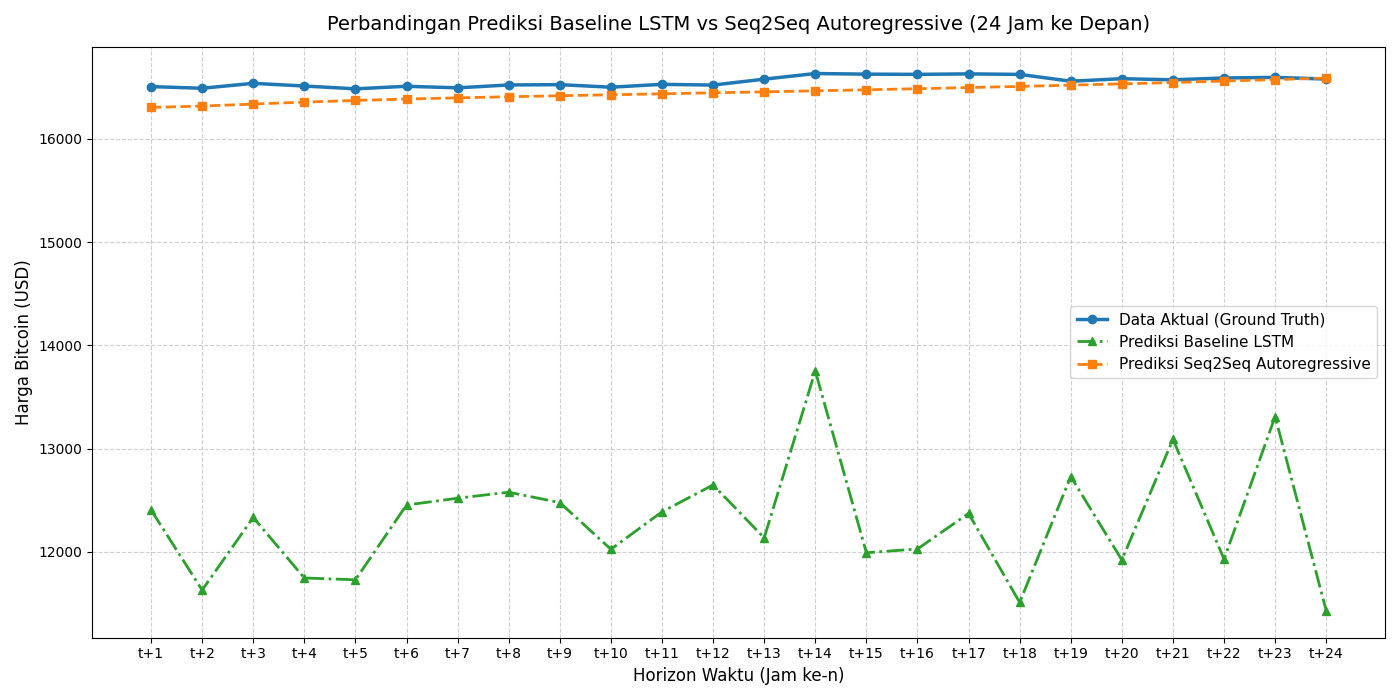

Jam ke,Data Aktual (USD),Prediksi Baseline (USD),Selisih Baseline (USD),Prediksi Seq2Seq (USD),Selisih Seq2Seq (USD)
1,16507.189453,12406.839844,4100.350098,16305.650391,201.539993
2,16491.330078,11631.139648,4860.189941,16318.730469,172.600006
3,16538.890625,12333.879883,4205.009766,16338.320312,200.559998
4,16513.000000,11748.070312,4764.930176,16357.160156,155.839996
5,16485.660156,11730.360352,4755.299805,16373.280273,112.379997
6,16510.380859,12454.759766,4055.620117,16386.810547,123.570000
7,16495.429688,12520.500000,3974.919922,16398.470703,96.959999
8,16523.210938,12578.820312,3944.389893,16408.949219,114.260002
9,16526.130859,12478.219727,4047.899902,16418.750000,107.379997
10,16501.599609,12026.150391,4475.450195,16428.220703,73.379997


In [ ]:
# 14. Visualisasi Perbandingan Prediksi Baseline LSTM vs Seq2Seq Autoregressive
sample_idx = 10
actual_scaled = y_test[sample_idx]
pred_seq2seq_scaled = autoregressive_preds[sample_idx]
pred_baseline_scaled = pred_baseline[sample_idx]

# Inverse scale ke satuan mata uang riil (USD)
actual_usd = target_scaler.inverse_transform(actual_scaled).flatten()
pred_seq2seq_usd = target_scaler.inverse_transform(pred_seq2seq_scaled).flatten()
pred_baseline_usd = target_scaler.inverse_transform(pred_baseline_scaled).flatten()
diff_seq2seq_usd = np.abs(actual_usd - pred_seq2seq_usd)
diff_baseline_usd = np.abs(actual_usd - pred_baseline_usd)

# 1. Line Chart Plot: Perbandingan Kedua Model
plt.figure(figsize=(14, 7))
hours = [f"t+{i+1}" for i in range(HORIZON)]
plt.plot(hours, actual_usd, marker='o', color='#1f77b4', linewidth=2.5, label='Data Aktual (Ground Truth)')
plt.plot(hours, pred_baseline_usd, marker='^', color='#2ca02c', linewidth=2.0, linestyle='-.', label='Prediksi Baseline LSTM')
plt.plot(hours, pred_seq2seq_usd, marker='s', color='#ff7f0e', linewidth=2.0, linestyle='--', label='Prediksi Seq2Seq Autoregressive')
plt.title("Perbandingan Prediksi Baseline LSTM vs Seq2Seq Autoregressive (24 Jam ke Depan)", fontsize=14, pad=12)
plt.xlabel("Horizon Waktu (Jam ke-n)", fontsize=12)
plt.ylabel("Harga Bitcoin (USD)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 2. Tabel Perbandingan Kedua Model vs Aktual
comparison_df = pd.DataFrame({
    "Jam ke": [f"{i+1}" for i in range(HORIZON)],
    "Data Aktual (USD)": np.round(actual_usd, 2),
    "Prediksi Baseline (USD)": np.round(pred_baseline_usd, 2),
    "Selisih Baseline (USD)": np.round(diff_baseline_usd, 2),
    "Prediksi Seq2Seq (USD)": np.round(pred_seq2seq_usd, 2),
    "Selisih Seq2Seq (USD)": np.round(diff_seq2seq_usd, 2)
})
print("\nTabel Perbandingan Data Aktual vs Prediksi Kedua Model (24 Jam ke Depan):")
display(comparison_df)

## Kesimpulan dan Pencapaian Proyek
1. **Pipeline Data & Eksplorasi**: Berhasil melakukan feature engineering (*rolling statistics*), dekomposisi time series (tren, musiman 24 jam, residual), serta analisis lag (ACF & PACF) untuk menentukan window size 48 jam secara objektif. Pembagian data dan penskalaan dilakukan secara kronologis tanpa adanya *data leakage*.
2. **Kustomisasi Arsitektur Model**:
   - `CustomDense` dibuat dari nol menggunakan `tf.keras.layers.Layer`.
   - `CustomMultiHeadAttention` dibuat dari nol untuk memetakan representasi *Query, Key, Value* dan mekanisme *scaled dot-product attention*.
   - Layer kustom tambahan seperti `CustomLayerNormalization` dan `CustomDropout` berhasil diintegrasikan pada Baseline LSTM dan Seq2Seq LSTM.
   - Model Seq2Seq dibangun dengan **Functional API** dan **Model Subclassing**.
3. **Kustomisasi Pelatihan (Custom Training)**:
   - Pelatihan kustom dieksekusi menggunakan **`tf.GradientTape`** dengan *gradient clipping* (`tf.clip_by_norm`).
   - Menerapkan **`HorizonWeightedMAE`** untuk memberikan penalti proporsional pada horizon waktu yang lebih jauh.
   - Menerapkan callback kustom **`CustomEarlyStopping`** dan **`CustomReduceLROnPlateau`**.
4. **Hasil Evaluasi**:
   - Inferensi prediksi pada data uji dilakukan menggunakan **Baseline LSTM** (prediksi langsung) dan **Seq2Seq Autoregressive Decoding** untuk 24 jam ke depan.
   - Kedua model dievaluasi dan dibandingkan secara langsung pada window data test yang sama, lengkap dengan visualisasi plot dan tabel perbandingan.
   - Nilai Test MAE Seq2Seq Autoregressive yang dicapai adalah **0.00661**, jauh lebih rendah daripada batas kriteria penilaian yaitu **0.015 MAE**.
   - Seluruh model wajib dan opsional berhasil disimpan dalam format `.keras` dan siap untuk diserahkan sebagai submission akhir berstandar **Bintang 5 (Advanced)**.